# Python and Sionna RT Environment Config

In [1]:
import importlib
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import sionna
import sionna.rt
from sionna.rt import (
    load_scene, PlanarArray, Transmitter, Receiver, Camera,
    PathSolver, RadioMapSolver, subcarrier_frequencies
)

import SceneConfigSionna2
import BeamformingCalc
from SceneConfigSionna2 import SceneConfigSionna
from BeamformingCalc import svd_bf, nulling_bf

# Reloads (optional)
importlib.reload(SceneConfigSionna2)
importlib.reload(BeamformingCalc)


<module 'BeamformingCalc' from '/workspace/shizhen/NTN-NULLING-SYS-BP/BeamformingCalc.py'>

In [ ]:
# scene_dir = Path("/workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km")
# scene_path = scene_dir / "10km_times_10km.xml" if scene_dir.is_dir() else scene_dir
# if not scene_path.is_file():
#     raise FileNotFoundError(f"Scene XML not found: {scene_path}")
# print(f"Loading scene from: {scene_path}")
# scene = load_scene(str(scene_path))
scene = load_scene("/home/sj4025/my_project/NTN-Nulling/Denver_Scene/blouder_plane_itu3/boulder_plane_itu.xml")
# scene = load_scene("/workspace/shizhen/NTN-Nulling/Denver_Scene/Boulder/Boulder.xml")


Loading scene from: /workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km/10km_times_10km.xml


Parmeters

In [3]:
import importlib
import SceneConfigSionna2
importlib.reload(SceneConfigSionna2)

from SceneConfigSionna2 import SceneConfigSionna
SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)

x range: [-5024.417, 5015.583]
y range: [-5047.131, 5042.869]


In [4]:
ntn_rx=100
tn_rx=100
bs_row = 4
bs_col = 4
nbs = bs_row*bs_col
azimuth = np.random.uniform(0, 360)
elevation = np.random.uniform(35, 90)
fc = 9.99e9  # 
nsect = 3
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows*tx_antenna_cols
tn_antennas = tn_rx_antenna_rows*tn_rx_antenna_cols



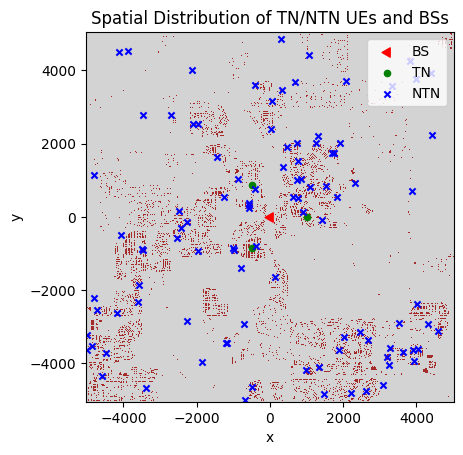

In [5]:
SceneConfig.compute_positions(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=True,
    bs_grid=(bs_row, bs_col),
    bs_boundary=3000,
    tn_building_ratio="sector",   # 0.5 -> 随机且50%在building
    # tn_building_ratio="0.6",   # 0.5 -> 随机且50%在building
    tn_distance=1000,
    ntn_building_ratio=0.7,
    plot_grid=True,
    plot_bs=True,
    plot_tn=True,
    plot_ntn=True
)
tn_pos = SceneConfig.tn_pos
tx_pos = SceneConfig.tx_pos
rx_ntn_pos = SceneConfig.rx_ntn_pos


Run Simu

In [6]:
SceneConfig.compute_paths(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=3,
    bandwidth=100e6,
    tx_power_dbm=30
    
)
tn_bs_index = SceneConfig.tn_bs_index
tn_sector_index = SceneConfig.tn_sector_index
cir_tn = SceneConfig.a_tn
cir_ntn = SceneConfig.a_ntn

In [7]:
tn_sector_index

array([0, 1, 2])

In [8]:
tn_bs_index

array([0, 0, 0])

In [9]:

# --- Params for post-processing ---
EkT = -174    # Noise energy in dBm/Hz
B = 100e6
Tx_power_dbm = 30
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)

NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B) + NF_bs - 30) / 10)

time = 20e-6
N0_sigma = N0_vsat / Tx_power / time

lambda_ranges = [0, 1e1, 1e3, 1e5]

snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10**(inr_threshold/10) * N0_bs * tx_antennas / Tx_power)
h_tn_th = np.sqrt(10**(snr_threshold/10) * N0_bs * tx_antennas / Tx_power)



# ===== Post-processing (beamforming / SNR / INR) =====

# cir tensors already available:
#   cir_tn = SceneConfig.a_tn
#   cir_ntn = SceneConfig.a_ntn

h_tn_all = np.sum(cir_tn, axis=4).squeeze()
if h_tn_all.ndim == 3:
    h_tn_all = h_tn_all.reshape(h_tn_all.shape[0], 1, h_tn_all.shape[1], h_tn_all.shape[2])

h_ntn_all = np.sum(cir_ntn, axis=4).squeeze()
if h_ntn_all.ndim == 3:
    # h_ntn_all = h_ntn_all.reshape(1, h_ntn_all.shape[0], h_ntn_all.shape[1])
    h_ntn_all = h_ntn_all.reshape(h_ntn_all.shape[0], 1, h_ntn_all.shape[1], h_ntn_all.shape[2])


interfered_ntn = np.count_nonzero(np.any(h_ntn_all != 0, axis=(2, 3)))


In [10]:
interfered_ntn

36

In [11]:
h_ntn_all.shape

(100, 1, 3, 64)

In [12]:

eps = 1e-12  # avoid log10(0)
snr_list = []
h_ntn_dB_list = []
h_tn_dB_list = []

w_t_record = []
v_null_record = {l: [] for l in lambda_ranges}
v_null_t_index = {l: [] for l in lambda_ranges}

eigen_value_dict = {l: [] for l in lambda_ranges}
snr_nulling_dict = {l: [] for l in lambda_ranges}
snr_nulling_hat_dict = {l: [] for l in lambda_ranges}
snr_degration_dict = {l: [] for l in lambda_ranges}
inr_nulling_dict = {l: [] for l in lambda_ranges}
inr_nulling_hat_dict = {l: [] for l in lambda_ranges}

best_tx_list = []
w_t_grouped, w_r_grouped, h_grouped = {}, {}, {}

# Use one-to-one TN pairing (nearest BS + sector)
for r in range(tn_pos.shape[0]):
    t = int(tn_bs_index[r]) * nsect + int(tn_sector_index[r])
    h_tn = h_tn_all[r, :, t, :].T  # Transfer to ntx*nrx
    h_tn_norm = np.linalg.norm(h_tn, ord='fro')
    h_tn_dB = 10 * np.log10(np.maximum(h_tn_norm**2, eps))
    h_tn_dB_list.append(h_tn_dB.item())

    if np.any(h_tn_norm > h_tn_th):
        w_t, w_r = svd_bf(h_tn, tx_antennas)
        snr = 10 * np.log10((np.abs(w_t.conj().T @ h_tn @ w_r)**2) * Tx_power / N0)

        best_tx_list.append(t)
        snr_list.append(snr.item())

        if t not in w_t_grouped:
            w_t_grouped[t], w_r_grouped[t], h_grouped[t] = [], [], []
        w_t_grouped[t].append(w_t)
        w_r_grouped[t].append(w_r)
        h_grouped[t].append(h_tn)

for t in w_t_grouped:
    w_t_grouped[t] = np.array(w_t_grouped[t])
    w_r_grouped[t] = np.array(w_r_grouped[t])
    h_grouped[t] = np.array(h_grouped[t])

if len(w_t_grouped) == 0:
    raise ValueError("No valid TN links after thresholding.")

min_count = min(len(w_t_grouped[t]) for t in w_t_grouped)

inr_list = []
ntn_kept_indices = []
mask_record = []

for m in range(min_count):
    valid_mask = np.zeros((ntn_rx,), dtype=bool)
    h_i_gain_sum = np.zeros((ntn_rx,), dtype=np.float64)
    h_i_null_gain_sum_dict = {l: np.zeros((ntn_rx,), dtype=np.float64) for l in lambda_ranges}
    h_i_null_gain_sum_hat_dict = {l: np.zeros((ntn_rx,), dtype=np.float64) for l in lambda_ranges}

    for t in range(nbs * nsect):
        if t not in w_t_grouped or len(w_t_grouped[t]) <= m:
            continue

        w_t = w_t_grouped[t][m]
        w_r = w_r_grouped[t][m]
        h = h_grouped[t][m]

        v_t = np.conj(w_t)
        w_t_record.append(v_t.copy())

        h_i = h_ntn_all[:,:, t, :]
        h_i_norms = np.linalg.norm(h_i, axis=2)
        h_ntn_dB = 10 * np.log10(np.maximum(h_i_norms**2, eps))
        h_ntn_dB_list.append(h_ntn_dB)

        mask = h_i_norms <= h_ntn_th
        valid_mask |= np.any(~mask, axis=1)
        mask_record.append(mask.copy())
        indices_kept = np.where(~mask)[0]
        ntn_kept_indices.append(indices_kept)

        noise = N0_sigma / np.sqrt(2) * (np.random.randn(*h_i.shape) + 1j * np.random.randn(*h_i.shape))
        h_i_hat = h_i + noise
        h_i[mask] = 0
        h_i_hat[mask] = 0

        det_ntn = np.count_nonzero(np.any(h_i != 0, axis=(1,2)))
        interference_term = np.einsum('uri,urj->ij', np.conj(h_i), h_i)   # (ntx, ntx)
        interference_term_hat = np.einsum('uri,urj->ij', np.conj(h_i_hat), h_i_hat)   # (ntx, ntx)
        
        
        h_i_gain = np.abs(np.sum(h_i @ w_t, axis=1).squeeze()/np.sqrt(h_i.shape[1]))**2

        # h_i_gain = (np.abs(np.matmul(w_t.conj().T, h_i)) ** 2).squeeze()
        h_i_gain_sum += h_i_gain

        for lambda_ in lambda_ranges:
            v_null, Q_1, Q_2, max_eigen_value = nulling_bf(h, w_r, interference_term, lambda_)
            v_null_hat, _, _, _ = nulling_bf(h, w_r, interference_term_hat, lambda_)

            v_null_t = np.conj(v_null)
            v_null_record[lambda_].append(v_null_t.copy())
            v_null_t_index[lambda_].append(t)

            eigen_value_dict[lambda_].append(max_eigen_value.item())

            snr_nulling = 10 * np.log10((np.abs(v_null.conj().T @ h @ w_r) ** 2) * Tx_power / N0)
            snr_nulling_hat = 10 * np.log10((np.abs(v_null_hat.conj().T @ h @ w_r) ** 2) * Tx_power / N0)

            snr_nulling_dict[lambda_].append(snr_nulling.item())
            snr_nulling_hat_dict[lambda_].append(snr_nulling_hat.item())

            snr_degration = 10 * np.log10((np.abs(w_t.conj().T @ h @ w_r) ** 2) / (np.abs(v_null_hat.conj().T @ h @ w_r) ** 2))
            snr_degration_dict[lambda_].append(snr_degration.item())

            # h_i_null_gain = (np.abs(np.matmul(v_null.conj().T, h_i)) ** 2).squeeze()
            h_i_null_gain = np.abs(np.sum(h_i @ v_null, axis=1).ravel()/np.sqrt(h_i.shape[1]))**2
            h_i_null_gain_sum_dict[lambda_] += h_i_null_gain

            # h_i_null_gain_hat = (np.abs(np.matmul(v_null_hat.conj().T, h_i)) ** 2).squeeze()
            h_i_null_gain_hat = np.abs(np.sum(h_i @ v_null_hat, axis=1).ravel()/np.sqrt(h_i.shape[1]))**2
            h_i_null_gain_sum_hat_dict[lambda_] += h_i_null_gain_hat

    inr = 10 * np.log10(np.maximum(h_i_gain_sum * Tx_power / N0, eps))
    inr_list.extend(inr[valid_mask])

    for lambda_ in lambda_ranges:
        inr_nulling = 10 * np.log10(np.maximum(h_i_null_gain_sum_dict[lambda_] * Tx_power / N0, eps))
        inr_nulling_dict[lambda_].extend(inr_nulling[valid_mask])

        inr_nulling_hat = 10 * np.log10(np.maximum(h_i_null_gain_sum_hat_dict[lambda_] * Tx_power / N0, eps))
        inr_nulling_hat_dict[lambda_].extend(inr_nulling_hat[valid_mask])

print("ntn_number_has_path_to BS:", interfered_ntn)
print("Used_tn:", min_count)

unique_ntn_kept_indices = np.unique(np.concatenate(ntn_kept_indices)) if ntn_kept_indices else np.array([], dtype=int)
left_ntn_pos = rx_ntn_pos[unique_ntn_kept_indices] if unique_ntn_kept_indices.size else np.empty((0, 3))
print("detected ntn number:", unique_ntn_kept_indices.shape)

# Optional: save
save_dict = {
    "w_t_record": np.array(w_t_record),
    "ntn_pos": np.array(left_ntn_pos),
    "tn_pos": np.array(tn_pos),
}

for lambda_ in v_null_record:
    save_dict[f"v_null_lambda_{lambda_}"] = np.array(v_null_record[lambda_])

np.savez("beamforming_results.npz", **save_dict)








ntn_number_has_path_to BS: 36
Used_tn: 1
detected ntn number: (15,)


In [13]:
min_count

1

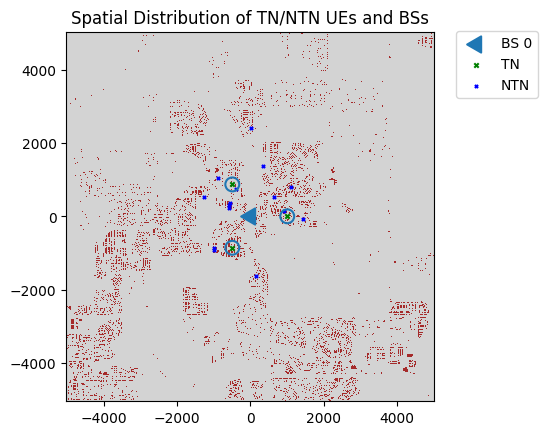

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# background
colors = ['lightgray', 'brown']
cmap_bg = ListedColormap(colors)

extent = SceneConfig.extent
point_type = SceneConfig.point_type

tn_bs_index = SceneConfig.tn_bs_index

plt.figure()
plt.imshow(point_type, cmap=cmap_bg, interpolation='nearest', extent=extent)


# BS colors: high-contrast palette
cmap_bs = plt.get_cmap("tab10")
n_bs = tx_pos.shape[0]
bs_colors = [cmap_bs(i % 10) for i in range(n_bs)]


# BS triangles (bigger and more visible)
bs_marker = (3, 0, -30)
for i in range(n_bs):
    plt.scatter(
        tx_pos[i, 0], tx_pos[i, 1],
        c=[bs_colors[i]],
        marker=bs_marker,
        s=180,           # bigger
        linewidths=1.5,  # thicker edge
        # edgecolors='k',  # black edge for contrast
        label=f"BS {i}"
    )


# TN points (same as compute_positions: green x)
plt.scatter(tn_pos[:, 0], tn_pos[:, 1], color='green', marker='x', s=10, label='TN')

# NTN points (same as compute_positions: blue x)
plt.scatter(left_ntn_pos[:, 0], left_ntn_pos[:, 1], color='blue', marker='x', s=5, label='NTN')

# Outer circles on TN, color matched to its BS
for i in range(tn_pos.shape[0]):
    bs_id = int(tn_bs_index[i])
    plt.scatter(
        tn_pos[i, 0], tn_pos[i, 1],
        edgecolors=bs_colors[bs_id], facecolors='none',
        marker='o', s=100, linewidths=1.5
    )

# plt.title('Spatial Distribution of TN/NTN and BSs')
plt.title('Spatial Distribution of TN/NTN UEs and BSs')

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.02), fontsize=10, frameon=True)

import os
# save_path = "/home/sj4025/my_project/ntn_int_nulling/map.png"
# os.makedirs(os.path.dirname(save_path), exist_ok=True)
# plt.savefig(save_path, dpi=300, format='png')
plt.show()


Different Lambda_

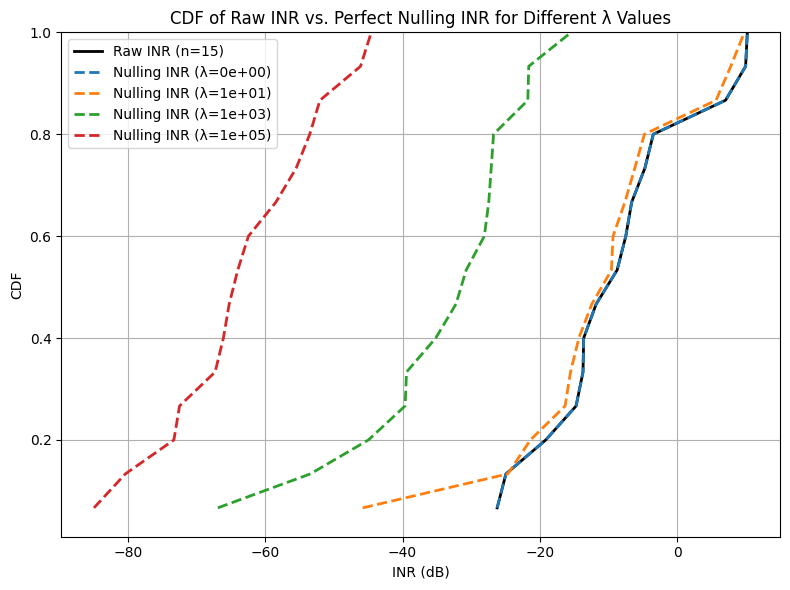

In [15]:
# Create a new figure
plt.figure(figsize=(8, 6))

# ------- Plot raw INR (no nulling) -------
inr_array = np.array(inr_list)
inr_array = inr_array[np.isfinite(inr_array)]
inr_sorted = np.sort(inr_array)
if len(inr_sorted) > 0:
    cdf_inr = np.arange(1, len(inr_sorted) + 1) / len(inr_sorted)
    plt.plot(inr_sorted, cdf_inr, label=f"Raw INR (n={len(inr_sorted)})", linewidth=2, color='black')

# ------- Plot INR Nulling for each lambda -------
for lambda_ in lambda_ranges:
    raw_inr_null_list = inr_nulling_dict[lambda_]
    inr_null_array = np.array(raw_inr_null_list)
    inr_null_array = inr_null_array[np.isfinite(inr_null_array)]
    inr_null_sorted = np.sort(inr_null_array)

    if len(inr_null_sorted) > 0:
        cdf_inr_null = np.arange(1, len(inr_null_sorted) + 1) / len(inr_null_sorted)
        plt.plot(inr_null_sorted, cdf_inr_null,
                #  label=f"Nulling INR (λ={lambda_:.0e}, n={len(inr_null_sorted)})",
                label=f"Nulling INR (λ={lambda_:.0e})",
                 linestyle="--", linewidth=2)

# ------- Make the plot pretty -------
plt.xlabel("INR (dB)")
plt.ylabel("CDF")
plt.title("CDF of Raw INR vs. Perfect Nulling INR for Different λ Values")
plt.grid(True)
plt.legend()
plt.ylim([0.01, 1])
plt.tight_layout()
plt.show()


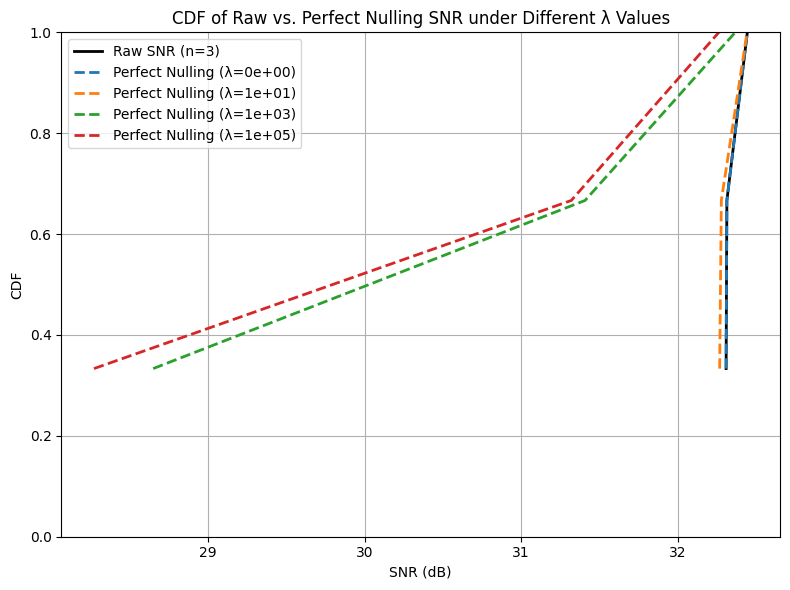

In [16]:
plt.figure(figsize=(8, 6))
# ------- Plot raw SNR (no nulling) -------
snr_array = np.array(snr_list)
snr_array = snr_array[np.isfinite(snr_array)]
snr_sorted = np.sort(snr_array)

if len(snr_sorted) > 0:
    cdf_snr = np.arange(1, len(snr_sorted) + 1) / len(snr_sorted)
    plt.plot(snr_sorted, cdf_snr, label=f"Raw SNR (n={len(snr_sorted)})", linewidth=2, color='black')

# ------- Plot Nulling SNR for each lambda -------
for lambda_ in lambda_ranges:
    # Ideal interference known
    snr_null = np.array(snr_nulling_dict[lambda_])
    snr_null = snr_null[np.isfinite(snr_null)]
    snr_null_sorted = np.sort(snr_null)

    if len(snr_null_sorted) > 0:
        cdf_snr_null = np.arange(1, len(snr_null_sorted) + 1) / len(snr_null_sorted)
        plt.plot(snr_null_sorted, cdf_snr_null,
                 label=f"Perfect Nulling (λ={lambda_:.0e})", linestyle='--', linewidth=2)


# ------- Make the plot nice -------
plt.xlabel("SNR (dB)")
plt.ylabel("CDF")
plt.title("CDF of Raw vs. Perfect Nulling SNR under Different λ Values")
plt.grid(True)
plt.legend()
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


Different Satellite Angle

In [17]:
# CODEx_FIXED: radiomap render function (no npz required)
import mitsuba as mi
from sionna.rt import RadioMapSolver, Camera, Receiver
import numpy as np
import matplotlib.pyplot as plt

try:
    from sionna.rt import transform_mesh
except Exception:
    transform_mesh = None


def _get_terrain_mesh(scene, terrain_name="Terrain", z_offset=0.1):
    if hasattr(scene, "objects") and terrain_name in scene.objects:
        terrain = scene.objects[terrain_name].clone(as_mesh=True)
    else:
        terrain = None
        if hasattr(scene, "objects"):
            for name in scene.objects.keys():
                if "terrain" in name.lower() or "plane" in name.lower():
                    terrain = scene.objects[name].clone(as_mesh=True)
                    break
        if terrain is None:
            return None
    if transform_mesh is not None:
        transform_mesh(terrain, translation=[0, 0, z_offset])
    else:
        raise RuntimeError("transform_mesh not available in your sionna version")
    return terrain


def _build_precoding_from_record(scene, nsect, lambda_):
    if lambda_ not in v_null_record or len(v_null_record[lambda_]) == 0:
        raise ValueError(f"No v_null_record for lambda={lambda_}")

    t_to_v = {}
    for t, v in zip(v_null_t_index[lambda_], v_null_record[lambda_]):
        t = int(t)
        if t not in t_to_v:
            t_to_v[t] = np.asarray(v).reshape(-1).astype(np.complex64)

    tx_names = list(scene.transmitters)
    if len(tx_names) == 0:
        raise ValueError("scene.transmitters is empty. Run compute_paths first.")

    num_tx_ant = next(iter(t_to_v.values())).shape[0]
    precoding = np.zeros((len(tx_names), num_tx_ant), dtype=np.complex64)

    for i, name in enumerate(tx_names):
        if not name.startswith("tx-"):
            continue
        parts = name.split("-")
        if len(parts) != 3:
            continue
        try:
            bs_idx = int(parts[1])
            sec_idx = int(parts[2])
        except ValueError:
            continue
        t = bs_idx * nsect + sec_idx
        if t in t_to_v:
            precoding[i, :] = t_to_v[t]

    return precoding


def _cast_solver_seed(seed):
    if seed is None:
        return None
    for type_name in ("UInt", "UInt32", "UInt64"):
        t = getattr(mi, type_name, None)
        if t is not None:
            try:
                return t(int(seed))
            except Exception:
                pass
    try:
        import drjit as dr
        return dr.uint32(int(seed))
    except Exception:
        return int(seed)




def _patch_sampler_seed_compat(solver):
    """Patch sampler.seed to support both (seed) and (seed, wavefront_size)."""
    sampler = getattr(solver, "_sampler", None)
    if sampler is None:
        return
    cls = sampler.__class__
    if getattr(cls, "_codex_seed_patched", False):
        return

    orig_seed = getattr(cls, "seed", None)
    if orig_seed is None:
        return

    def seed_compat(self, seed, wavefront_size=4294967295):
        try:
            return orig_seed(self, seed, int(wavefront_size))
        except TypeError:
            return orig_seed(self, seed)

    try:
        cls.seed = seed_compat
        cls._codex_seed_patched = True
    except Exception:
        pass


def render_nulling_radiomap_all(scene, nsect, lambda_,
                                center=None, size=None, cell_size=(10, 10),
                                max_depth=3, samples_per_tx=2**18,
                                metric="inr_ntn",
                                show_scene=False,
                                show_2d=False,
                                use_terrain=True,
                                terrain_name="Terrain",
                                terrain_z_offset=1.5,
                                show_tn=False,
                                show_left_ntn=False,
                                show_legend=False,
                                legend_loc="upper right",
                                tn_color=(0.0, 0.35, 1.0),
                                left_ntn_color=(0.0, 1.0, 1.0),
                                tn_display_radius=120,
                                left_ntn_display_radius=90,
                                rm_vmin=None, rm_vmax=None,
                                camera_pos=[0, 0, 9000],
                                camera_look_at=[0, 0, 0],
                                render_resolution=(5000, 5000),
                                render_fov=95,
                                render_num_samples=16,
                                render_retry_on_oom=True,
                                seed=1,
                                precoding_matrix=None):

    for rx_name in list(scene.receivers):
        scene.remove(rx_name)

    tx_names = list(scene.transmitters)
    if len(tx_names) == 0:
        raise ValueError("scene.transmitters is empty. Run compute_paths first.")

    if precoding_matrix is not None:
        precoding = np.asarray(precoding_matrix, dtype=np.complex64)
        if precoding.ndim != 2:
            raise ValueError(f"precoding_matrix must be 2-D, got shape {precoding.shape}")
        if precoding.shape[0] != len(tx_names):
            raise ValueError(f"precoding_matrix row mismatch: got {precoding.shape[0]}, expected {len(tx_names)}")
    else:
        precoding = _build_precoding_from_record(scene, nsect, lambda_)

    nz = np.linalg.norm(precoding, axis=1) > 0
    print(f"TX total: {len(tx_names)}, with precoding: {np.count_nonzero(nz)}")
    if np.count_nonzero(nz) == 0:
        raise ValueError("All precoding vectors are zero.")

    precoding_vec = (
        mi.TensorXf(np.ascontiguousarray(precoding.real.astype(np.float32))),
        mi.TensorXf(np.ascontiguousarray(precoding.imag.astype(np.float32))),
    )

    rm_solver = RadioMapSolver()
    # Mitsuba sampler requires wavefront_size <= 2^32-1.
    num_tx = len(tx_names)
    max_wavefront = (2**32) - 1
    max_samples_per_tx = max(1, max_wavefront // max(1, num_tx))
    eff_samples_per_tx = int(min(int(samples_per_tx), int(max_samples_per_tx)))
    if eff_samples_per_tx != int(samples_per_tx):
        print(f"samples_per_tx clipped from {int(samples_per_tx)} to {eff_samples_per_tx} for {num_tx} TX")

    _patch_sampler_seed_compat(rm_solver)
    seed_cast = _cast_solver_seed(seed)

    measurement_surface = None
    if use_terrain:
        measurement_surface = _get_terrain_mesh(scene, terrain_name=terrain_name, z_offset=terrain_z_offset)

    if measurement_surface is not None:
        rm = rm_solver(scene,
                       measurement_surface=measurement_surface,
                       max_depth=max_depth,
                       samples_per_tx=eff_samples_per_tx,
                       precoding_vec=precoding_vec,
                       cell_size=cell_size,
                       seed=seed_cast)
    else:
        if center is not None:
            center = [float(center[0]), float(center[1]), float(center[2])]
        if size is not None:
            size = [float(size[0]), float(size[1])]

        rm = rm_solver(scene,
                       max_depth=max_depth,
                       samples_per_tx=eff_samples_per_tx,
                       precoding_vec=precoding_vec,
                       cell_size=cell_size,
                       center=center,
                       size=size,
                       orientation=[0, 0, 0],
                       seed=seed_cast)

    if show_scene:
        temp_names = []
        if show_tn and 'tn_pos' in globals():
            for i, pos in enumerate(tn_pos):
                name = f"tmp-tn-{i}"
                scene.add(Receiver(name=name, position=pos, color=tuple(tn_color), display_radius=tn_display_radius))
                temp_names.append(name)
        if show_left_ntn and 'left_ntn_pos' in globals() and left_ntn_pos is not None:
            for i, pos in enumerate(left_ntn_pos):
                name = f"tmp-leftntn-{i}"
                scene.add(Receiver(name=name, position=pos, color=tuple(left_ntn_color), display_radius=left_ntn_display_radius))
                temp_names.append(name)

        cam_dist = float(np.linalg.norm(np.asarray(camera_pos, dtype=float) - np.asarray(camera_look_at, dtype=float)))
        if cam_dist > 9800:
            print(f"warning: camera distance {cam_dist:.1f}m is close to/exceeds Sionna far_clip=10000; image may be blank")
        cam = Camera(position=list(camera_pos), look_at=list(camera_look_at))
        render_kwargs = dict(camera=cam,
                             radio_map=rm,
                             resolution=tuple(render_resolution),
                             fov=float(render_fov),
                             rm_show_color_bar=True,
                             rm_vmin=rm_vmin,
                             rm_vmax=rm_vmax,
                             rm_metric=metric,
                             num_samples=int(render_num_samples))
        try:
            scene.render(**render_kwargs)
        except RuntimeError as e:
            msg = str(e).lower()
            if (not render_retry_on_oom) or ("out of memory" not in msg):
                raise
            w, h = render_kwargs["resolution"]
            ns = int(render_kwargs["num_samples"])
            w2, h2 = max(1024, w//2), max(1024, h//2)
            ns2 = max(4, ns//2)
            print(f"render OOM: retry with resolution={(w2, h2)}, num_samples={ns2}")
            render_kwargs["resolution"] = (w2, h2)
            render_kwargs["num_samples"] = ns2
            scene.render(**render_kwargs)

        if show_legend:
            from matplotlib.lines import Line2D

            handles = [
                Line2D([0], [0], marker='o', linestyle='None', color='red',
                       markerfacecolor='red', markeredgecolor='red', markersize=8, label='BS')
            ]
            if show_tn:
                handles.append(
                    Line2D([0], [0], marker='o', linestyle='None', color=tuple(tn_color),
                           markerfacecolor=tuple(tn_color), markeredgecolor=tuple(tn_color),
                           markersize=8, label='TN')
                )
            if show_left_ntn:
                handles.append(
                    Line2D([0], [0], marker='o', linestyle='None', color=tuple(left_ntn_color),
                           markerfacecolor=tuple(left_ntn_color), markeredgecolor=tuple(left_ntn_color),
                           markersize=8, label='NTN')
                )

            try:
                fig = plt.gcf()
                ax = fig.axes[0] if len(fig.axes) > 0 else plt.gca()
                if legend_loc == 'upper left':
                    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.02, 0.98),
                              borderaxespad=0.0, frameon=True)
                else:
                    ax.legend(handles=handles, loc=legend_loc, frameon=True)
                plt.show()
            except Exception:
                fig_leg, ax_leg = plt.subplots(figsize=(4.8, 0.8))
                ax_leg.axis('off')
                ax_leg.legend(handles=handles, loc='center', ncol=len(handles), frameon=True)
                plt.show()

        for name in temp_names:
            if name in scene.receivers:
                scene.remove(name)
                
    return rm






In [18]:
# # CODEx_FIXED: direct render from in-memory v_null_record (no npz)
# import inspect

# src_check = inspect.getsource(render_nulling_radiomap_all)
# print('render has seed compat patch:', '_patch_sampler_seed_compat' in src_check)
# seed_obj = _cast_solver_seed(1)
# print('seed cast type:', type(seed_obj))

# render_nulling_radiomap_all(
#     scene, nsect, lambda_=1e5,
#     metric='inr_ntn',
#     show_scene=True,
#     use_terrain=False,
#     center=[0, 0, 100],
#     size=[10000, 10000],
#     cell_size=(10, 10),
#     max_depth=3,
#     samples_per_tx=10**8,
#     rm_vmin=-20, rm_vmax=45,
#     show_tn=True,
#     show_left_ntn=True,
#     seed=1
# )




TX total: 3, with precoding: 3


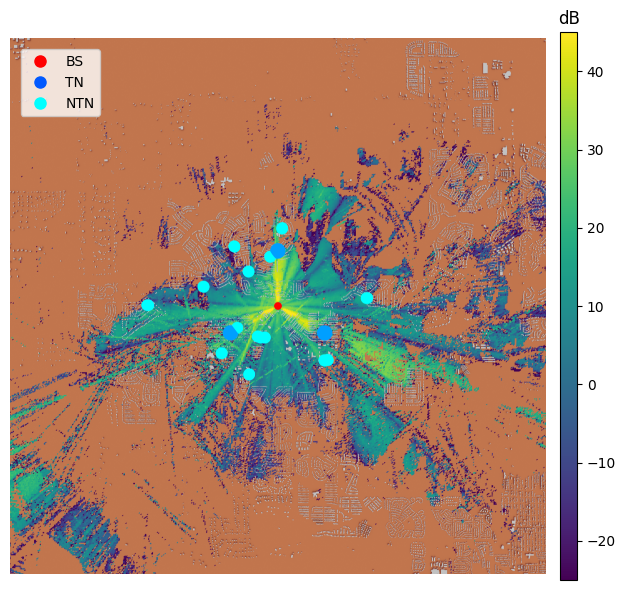

In [19]:
rm = render_nulling_radiomap_all(
    scene, nsect, lambda_=1e5,
    metric='inr_ntn',
    show_scene=True,
    show_legend=True,
    legend_loc='upper left',
    use_terrain=True,
    terrain_name="terrain",
    terrain_z_offset=2.5,
    cell_size=(5, 5),
    max_depth=3,
    samples_per_tx=10*10**7,
    show_tn=True,
    show_left_ntn=True,
    tn_display_radius=140,
    left_ntn_display_radius=110,
    camera_pos=[0, 0, 5000],
    camera_look_at=[0, 0, 0],
    render_resolution=(9000, 9000),
    render_fov=90,
    rm_vmin=-25,
    rm_vmax=45,
    seed=1
)


In [20]:
scene.preview(
    paths= SceneConfig.paths_ntn,
    radio_map=rm,
    rm_metric="inr_ntn",   # 或 "rss" / "sinr"
    rm_vmin=-25,
    rm_vmax=45
    # rm_db_scale=True
)